# MobileNetV3-Large — Standard Training Baseline

**Purpose:** Direct comparison to `emp_model_knowledge_distilation.ipynb`.
Same model, same data, same transforms, same split — but trained with plain
cross-entropy instead of knowledge distillation.

The delta between this notebook and the distillation notebook isolates exactly
what the v6 teacher's soft labels contribute.

| | This notebook | Distillation notebook |
|---|---|---|
| Model | MobileNetV3-Large | MobileNetV3-Large |
| Loss | CE + label smoothing | α·KL(teacher) + (1-α)·CE |
| Teacher | — | v6 full pipeline (92.71%) |
| Transforms | identical | identical |
| Split | identical (seed=42) | identical (seed=42) |
| Export | ONNX int8 | ONNX int8 |

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re, math, copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from datetime import datetime
from pathlib import Path
from PIL import Image

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

DATA_DIR = r'/content/drive/MyDrive/coin_dataset' if ON_COLAB else r'/home/david/coin/FOR_TRAINNING'

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda:0


In [3]:
def folder_label(name):
    return re.sub(r'^\d+_', '', name)

image_dir     = Path(DATA_DIR)
filepaths     = sorted(image_dir.glob('*/side_a/*.jpg'))
unique_labels = sorted({folder_label(p.parent.parent.name) for p in filepaths})
label_encoder = {name: i for i, name in enumerate(unique_labels)}
raw_labels    = [folder_label(p.parent.parent.name) for p in filepaths]
labels_int    = [label_encoder[l] for l in raw_labels]

# Same GORDIAN II merge as all previous versions
MERGES        = {'GORDIAN II': 'GORDIAN I'}
kept_names    = [n for n in unique_labels if n not in MERGES]
new_enc       = {name: i for i, name in enumerate(kept_names)}
old_to_new    = {label_encoder[n]: new_enc[n] for n in kept_names}
for src, tgt in MERGES.items():
    old_to_new[label_encoder[src]] = new_enc[tgt]

all_labs      = torch.tensor([old_to_new[l] for l in labels_int], dtype=torch.long)
label_encoder = new_enc
idx_to_label  = {v: k for k, v in label_encoder.items()}
num_classes   = len(label_encoder)
print(f'{len(filepaths)} images  |  {num_classes} classes (after merge)')

62134 images  |  51 classes (after merge)


## Dataset & Transforms

Identical to the distillation notebook — same augmentation, same split seed.

In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.RandomHorizontalFlip(),
    T.RandomRotation(30),           # coins have no canonical orientation
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
val_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class CoinDataset(Dataset):
    def __init__(self, indices, transform):
        self.indices   = indices
        self.transform = transform

    def __len__(self): return len(self.indices)

    def __getitem__(self, i):
        idx  = self.indices[i]
        img  = Image.open(filepaths[idx]).convert('RGB')
        return self.transform(img), all_labs[idx]


# Exact same split as distillation notebook (and all v* embedding notebooks)
indices = np.arange(len(all_labs))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, shuffle=True, stratify=all_labs.numpy(), random_state=42)
train_idx, val_idx = train_test_split(
    train_idx, test_size=0.2, shuffle=True,
    stratify=all_labs.numpy()[train_idx], random_state=42)

train_ds = CoinDataset(train_idx, train_transform)
val_ds   = CoinDataset(val_idx,   val_transform)
test_ds  = CoinDataset(test_idx,  val_transform)
print(f'Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}')

Train: 39765  Val: 9942  Test: 12427


In [5]:
BATCH_SIZE = 128

train_labs_idx = all_labs[train_idx]
class_counts   = torch.bincount(train_labs_idx, minlength=num_classes).float()
beta           = 0.9999
effective_num  = 1.0 - torch.pow(beta, class_counts)
cb_weights     = (1.0 - beta) / effective_num
cb_weights     = cb_weights / cb_weights.sum() * num_classes

sample_weights = cb_weights[train_labs_idx]
train_sampler  = WeightedRandomSampler(sample_weights, num_samples=len(train_ds),
                                        replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler,
                           num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=4, pin_memory=True)
print(f'Loaders ready.  Batches/epoch: {len(train_loader)}')

# Class stats
name_to_prefix = {
    re.sub(r'^\d+_', '', p.name): int(re.match(r'^(\d+)_', p.name).group(1))
    for p in Path(DATA_DIR).iterdir()
    if p.is_dir() and (p / 'side_a').exists()
}
print('\nSmallest 5 classes (train):')
counts = torch.bincount(train_labs_idx, minlength=num_classes)
for idx in counts.argsort()[:5]:
    print(f'  {idx_to_label[idx.item()]}: {counts[idx].item()}')

Loaders ready.  Batches/epoch: 311

Smallest 5 classes (train):
  SEVERUS II: 194
  GORDIAN I: 252
  CONSTANTIUS I: 330
  VALERIAN: 392
  TRBONIANUS GALLUS: 396


## Model — MobileNetV3-Large

ImageNet pretrained, final layer replaced with 51-class head.
Identical to the distillation notebook — only the loss differs.

In [6]:
model = tvm.mobilenet_v3_large(weights=tvm.MobileNet_V3_Large_Weights.IMAGENET1K_V2)
in_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_features, num_classes)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'MobileNetV3-Large: {total_params / 1e6:.1f}M params')
print(f'Head: {in_features} → {num_classes} classes')

MobileNetV3-Large: 4.3M params
Head: 1280 → 51 classes


## Training — CE + Label Smoothing

Label smoothing 0.1 has helped in every version of the project (v3 onwards).
Everything else matches the distillation notebook: AdamW, cosine warmup, 60 epochs.

In [7]:
EPOCHS    = 60
LR        = 3e-4
WD        = 1e-4
SMOOTHING = 0.1

cb_weights_dev = cb_weights.to(device)


def make_scheduler(optimizer, total_steps, warmup_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * prog))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def smoothed_ce(logits, targets, weight, smoothing=SMOOTHING):
    log_p  = F.log_softmax(logits, dim=-1)
    nll    = -log_p.gather(1, targets.unsqueeze(1)).squeeze(1)
    smooth = -log_p.mean(dim=-1)
    per_ex = (1 - smoothing) * nll + smoothing * smooth
    if weight is not None:
        per_ex = per_ex * weight[targets]
    return per_ex.mean()


optimizer   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
total_steps = EPOCHS * len(train_loader)
scheduler   = make_scheduler(optimizer, total_steps, warmup_steps=2 * len(train_loader))

best_val_acc, best_state = 0.0, None

for epoch in range(1, EPOCHS + 1):
    t0 = datetime.now()
    model.train()
    running_loss = 0.0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = smoothed_ce(model(imgs), labels, cb_weights_dev)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        running_loss += loss.item()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            correct += (model(imgs).argmax(-1) == labels).sum().item()
            total   += labels.size(0)
    val_acc  = correct / total
    improved = val_acc > best_val_acc
    if improved:
        best_val_acc = val_acc
        best_state   = copy.deepcopy(model.state_dict())

    if epoch <= 5 or epoch % 5 == 0 or improved:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'ep {epoch:3d}/{EPOCHS}  '
              f'loss {running_loss / len(train_loader):.4f}  '
              f'val {val_acc:.4f}  lr {lr_now:.2e}  '
              f'[{datetime.now() - t0}]' + (' <--' if improved else ''))

model.load_state_dict(best_state)
model.eval()
torch.save(model.state_dict(), 'emp_model_mobilenet_baseline.pth')
print(f'\nBest val acc: {best_val_acc:.4f}')

ep   1/60  loss 3.2149  val 0.2747  lr 1.50e-04  [0:01:02.872967] <--
ep   2/60  loss 1.8047  val 0.6122  lr 3.00e-04  [0:00:55.561167] <--
ep   3/60  loss 1.3581  val 0.7065  lr 3.00e-04  [0:01:00.969459] <--
ep   4/60  loss 1.1707  val 0.7483  lr 2.99e-04  [0:01:00.319351] <--
ep   5/60  loss 1.0635  val 0.7684  lr 2.98e-04  [0:00:56.823508] <--
ep   6/60  loss 1.0022  val 0.8083  lr 2.96e-04  [0:00:59.017008] <--
ep   7/60  loss 0.9508  val 0.8149  lr 2.95e-04  [0:00:59.649283] <--
ep   8/60  loss 0.9179  val 0.8205  lr 2.92e-04  [0:00:57.168839] <--
ep   9/60  loss 0.8914  val 0.8381  lr 2.89e-04  [0:00:59.876137] <--
ep  10/60  loss 0.8683  val 0.8433  lr 2.86e-04  [0:01:00.571250] <--
ep  11/60  loss 0.8537  val 0.8442  lr 2.83e-04  [0:00:57.163153] <--
ep  12/60  loss 0.8439  val 0.8512  lr 2.79e-04  [0:00:59.812716] <--
ep  13/60  loss 0.8284  val 0.8633  lr 2.74e-04  [0:01:00.329269] <--
ep  15/60  loss 0.8120  val 0.8586  lr 2.64e-04  [0:01:00.664383]
ep  18/60  loss 0.7930  

## Evaluation

In [8]:
model.eval()

def evaluate(loader, name):
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            correct += (model(imgs).argmax(-1) == labels).sum().item()
            total   += labels.size(0)
    acc = correct / total
    print(f'{name}: {acc:.4f}  ({correct}/{total})')
    return acc

val_acc  = evaluate(val_loader,  'Val ')
test_acc = evaluate(test_loader, 'Test')

Val : 0.8865  (8814/9942)
Test: 0.8902  (11063/12427)


Overall: 11063/12427 = 0.8902

Per-class (10 worst):
  38_VALERIAN: 52/122  (42.6%)
    -> 37_AEMILIAN: 30 (24.6%)
    -> 39_GALLIENUS: 24 (19.7%)
  41_QUINTILLUS: 62/140  (44.3%)
    -> 42_AURELIAN: 45 (32.1%)
    -> 40_CLAUDIUS GOTHICUS: 29 (20.7%)
  20_DIDIUS JULIANUS: 101/158  (63.9%)
    -> 21_SEPTIMUS SEVERUS: 47 (29.7%)
    -> 19_PERTINAX: 10 (6.3%)
  21_SEPTIMUS SEVERUS: 330/469  (70.4%)
    -> 20_DIDIUS JULIANUS: 116 (24.7%)
    -> 18_COMMODUS: 9 (1.9%)
  37_AEMILIAN: 113/152  (74.3%)
    -> 38_VALERIAN: 28 (18.4%)
    -> 39_GALLIENUS: 3 (2.0%)
  42_AURELIAN: 132/176  (75.0%)
    -> 41_QUINTILLUS: 39 (22.2%)
    -> 45_PROBUS: 3 (1.7%)
  39_GALLIENUS: 125/163  (76.7%)
    -> 38_VALERIAN: 26 (16.0%)
    -> 37_AEMILIAN: 4 (2.5%)
  36_TRBONIANUS GALLUS: 102/124  (82.3%)
    -> 34_TRAJAN DECIUS: 9 (7.3%)
    -> 33_PHILIP THE ARAB: 4 (3.2%)
  25_ELAGABALUS: 265/321  (82.6%)
    -> 22_CARACALLA: 26 (8.1%)
    -> 24_MACRINUS: 7 (2.2%)
  40_CLAUDIUS GOTHICUS: 138/167  (82.6%)
    -> 41

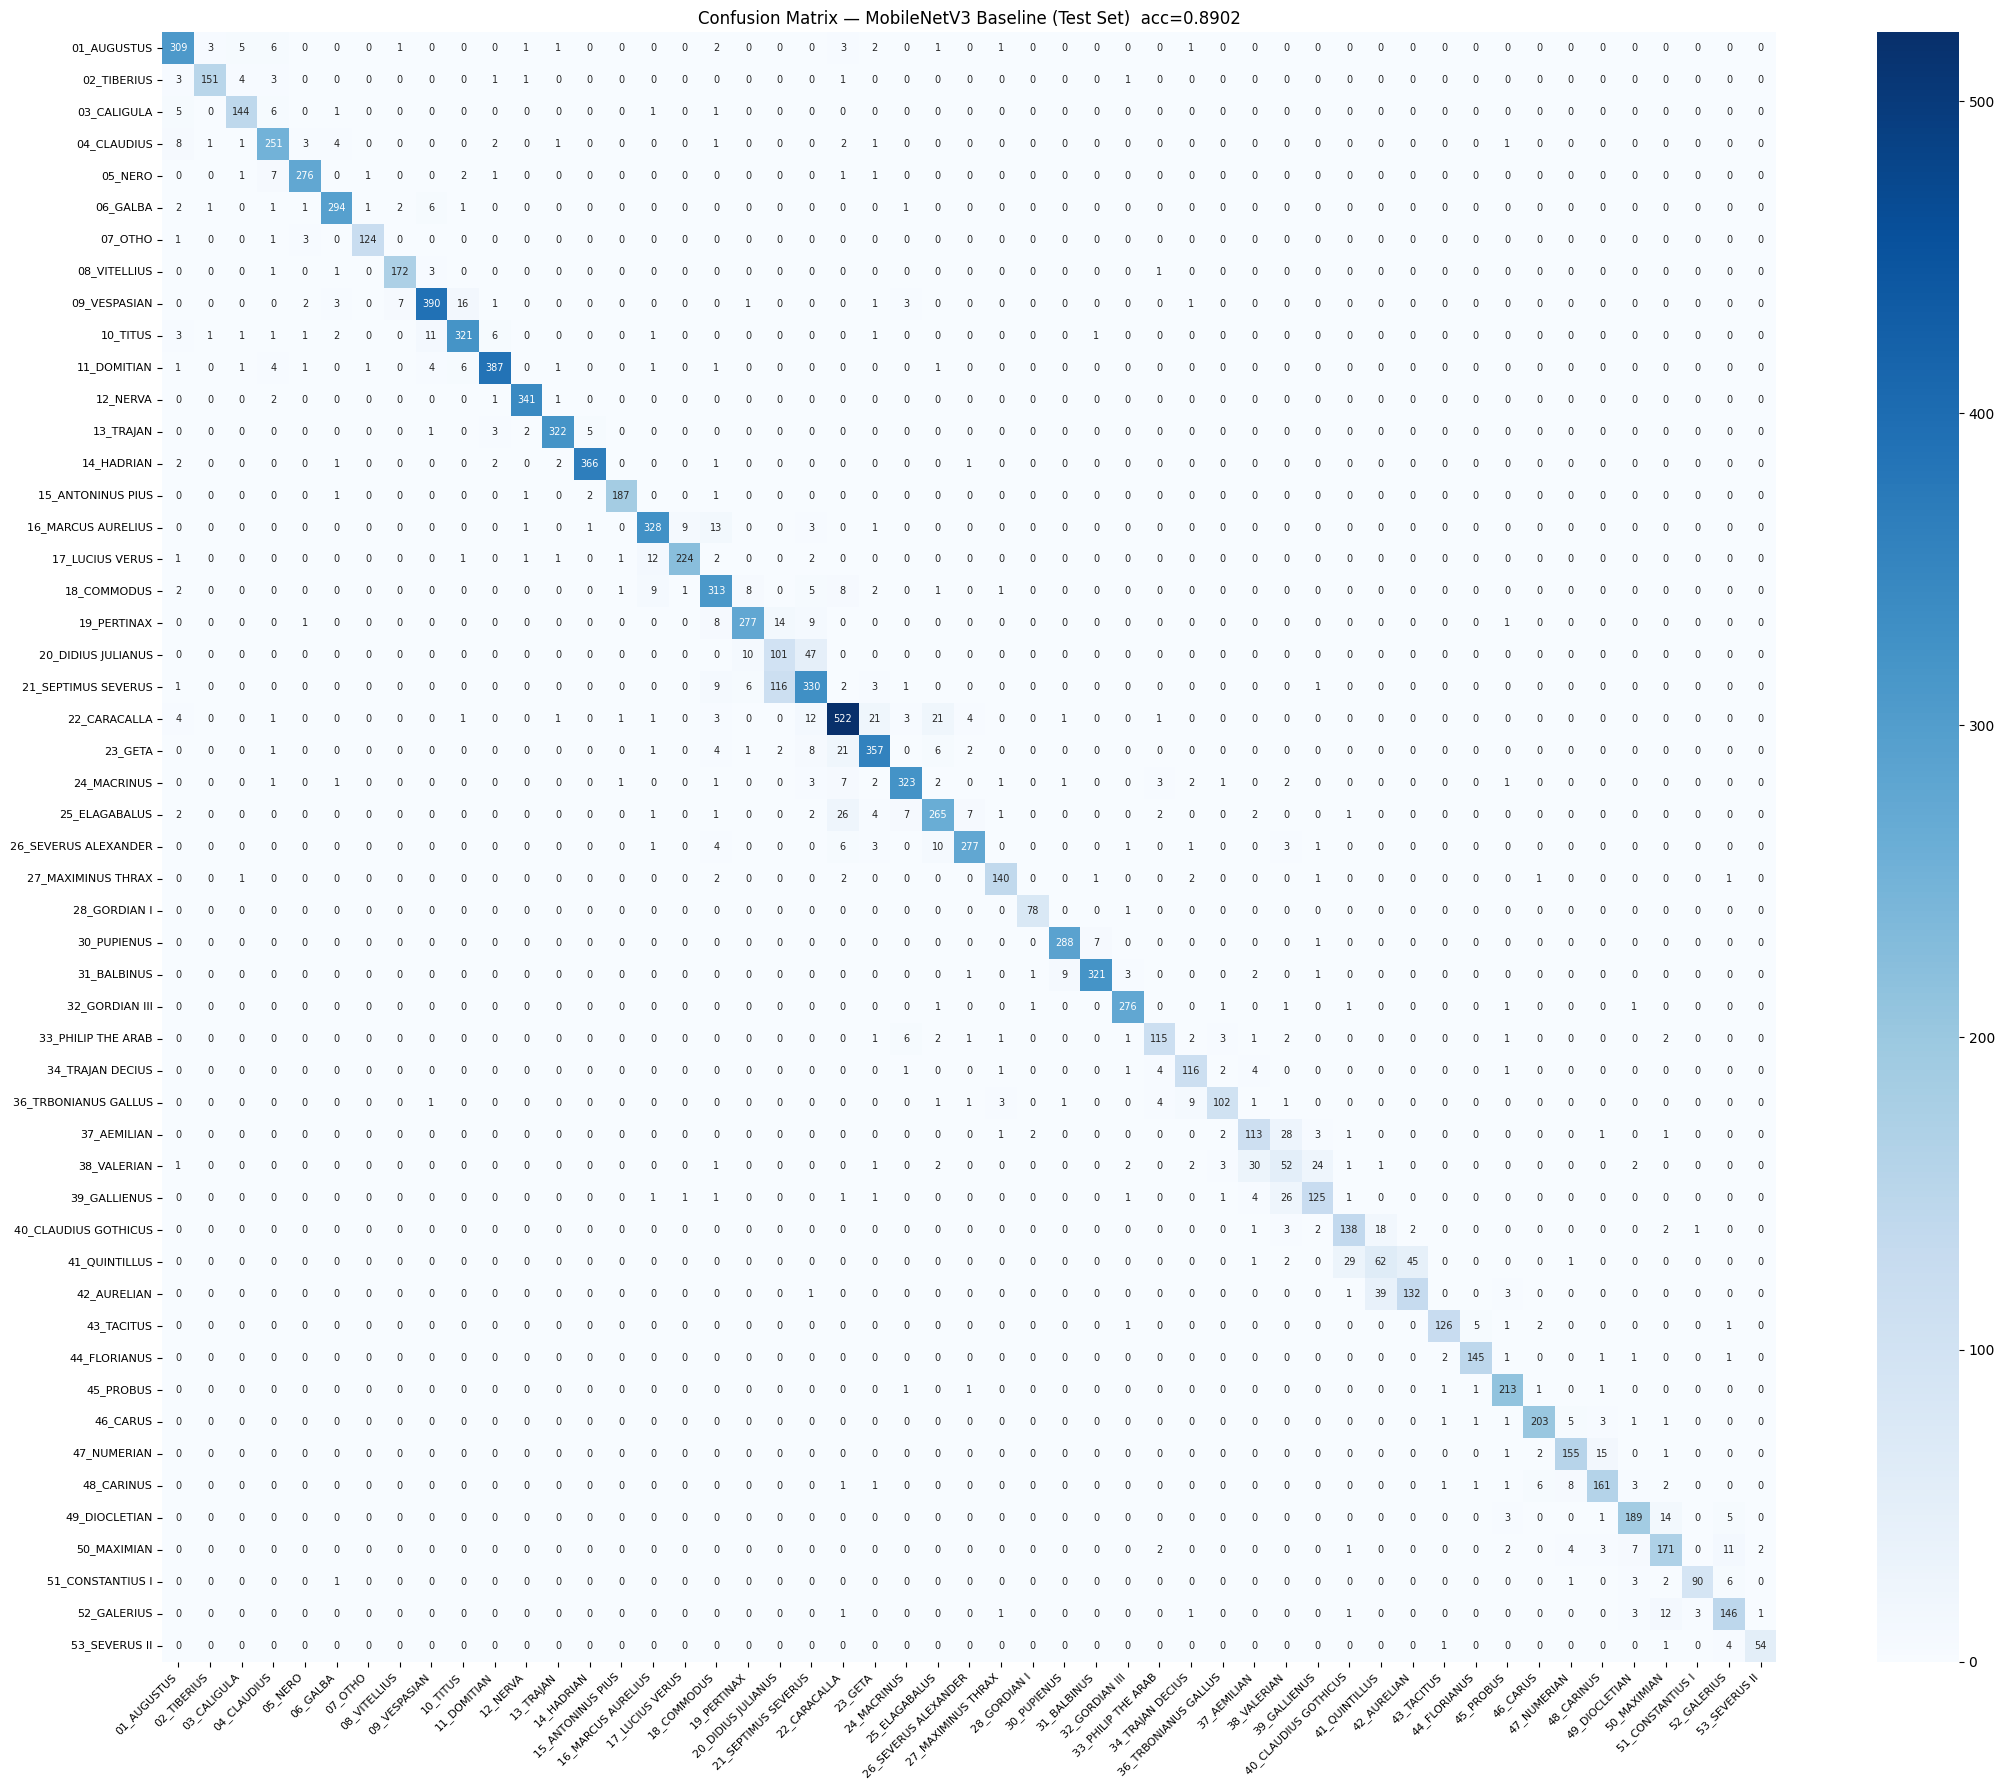

In [9]:
class_order   = sorted(range(num_classes), key=lambda i: name_to_prefix.get(idx_to_label[i], 99))
display_names = [f"{name_to_prefix.get(idx_to_label[i],99):02d}_{idx_to_label[i]}" for i in class_order]

cm = np.zeros((num_classes, num_classes), dtype=int)
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(-1)
        for t, p in zip(labels.cpu(), preds.cpu()):
            cm[t.item(), p.item()] += 1
cm = cm[np.ix_(class_order, class_order)]

row_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
print(f'Overall: {cm.diagonal().sum()}/{cm.sum()} = {cm.diagonal().sum()/cm.sum():.4f}\n')
print('Per-class (10 worst):')
for i in np.argsort(row_acc)[:10]:
    n_total = int(cm[i].sum()); n_correct = int(cm[i, i])
    print(f'  {display_names[i]}: {n_correct}/{n_total}  ({n_correct/max(n_total,1):.1%})')
    off = sorted(((j, int(cm[i,j])) for j in range(num_classes) if j!=i and cm[i,j]>0), key=lambda x:-x[1])
    for j, cnt in off[:2]:
        print(f'    -> {display_names[j]}: {cnt} ({cnt/max(n_total,1):.1%})')

plt.figure(figsize=(22, 18))
sns.heatmap(pd.DataFrame(cm, index=display_names, columns=display_names),
            annot=True, fmt='d', cmap='Blues', annot_kws={'size': 7})
plt.title(f'Confusion Matrix — MobileNetV3 Baseline (Test Set)  acc={test_acc:.4f}')
plt.xticks(rotation=45, ha='right', fontsize=8); plt.yticks(rotation=0, fontsize=8)
plt.tight_layout(); plt.show()

## ONNX Export + int8 Quantization

In [10]:
import onnx

model.eval().cpu()
dummy = torch.randn(1, 3, 224, 224)
onnx_path = 'coin_classifier_baseline.onnx'

torch.onnx.export(
    model, dummy, onnx_path,
    input_names=['image'], output_names=['logits'],
    dynamic_axes={'image': {0: 'batch_size'}, 'logits': {0: 'batch_size'}},
    opset_version=17,
)
onnx.checker.check_model(onnx_path)
size_fp32 = Path(onnx_path).stat().st_size / 1e6
print(f'Exported: {onnx_path}  ({size_fp32:.1f} MB fp32)')

ModuleNotFoundError: No module named 'onnx'

In [ ]:
from onnxruntime.quantization import quantize_dynamic, QuantType

int8_path = 'coin_classifier_baseline_int8.onnx'
quantize_dynamic(onnx_path, int8_path, weight_type=QuantType.QInt8)

size_int8 = Path(int8_path).stat().st_size / 1e6
print(f'Quantized: {int8_path}  ({size_int8:.1f} MB int8)')

In [ ]:
import onnxruntime as ort

sess_int8 = ort.InferenceSession(int8_path)
correct, total = 0, 0
for imgs, labels in test_loader:
    logits = sess_int8.run(None, {'image': imgs.numpy()})[0]
    correct += (logits.argmax(-1) == labels.numpy()).sum()
    total   += len(labels)
int8_acc = correct / total

print('=' * 50)
print('COMPARISON SUMMARY')
print('=' * 50)
print(f'Teacher  (v6 full pipeline)   : 92.71%')
print(f'Baseline (MobileNetV3, CE)    : {test_acc * 100:.2f}%  test  |  {size_int8:.1f}MB int8')
print(f'Baseline ONNX int8            : {int8_acc * 100:.2f}%  test')
print()
print('Run emp_model_knowledge_distilation.ipynb for the distillation number.')
print(f'Distillation gain = distil_acc - {test_acc * 100:.2f}%')